# DeepSeek-Foundations · Workbook 02

### Calculus & Automatic Differentiation — gradients, the chain rule, and how learning happens

**Series:** DeepSeek-Foundations v1.0 · **Runtime:** ~75 min · **Prereqs:** [Workbook 01](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/01_Linear_Algebra.ipynb) (lightly), high-school calculus

---

> **Abstract.** We introduce the calculus of learning: derivatives, partial derivatives, gradients, and the chain rule — and we show how a single mechanical procedure, reverse-mode automatic differentiation (backpropagation), turns any differentiable function into a learning machine. The central object of this workbook is the gradient $\nabla \mathcal{L}$, the vector that points in the direction of steepest *increase* of a loss $\mathcal{L}$, because every optimization algorithm in deep learning walks the opposite way. We derive the chain rule for scalar and vector compositions, measure why reverse mode beats forward mode, and — as this curriculum's Phase-2 deliverable — implement a complete reverse-mode autodiff engine from scratch in pure Python. We verify the engine's gradients against finite differences (gradient checking) and use it to train a small model end-to-end. By the close of this workbook, the reader will have written backpropagation by hand.

**How this fits the series.** This is workbook 02 of seven. [Workbook 01 — Linear Algebra](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/01_Linear_Algebra.ipynb) built the vectors and matrices that data lives in; this workbook builds the calculus that *moves* them; [Workbook 03 — Probability & Statistics](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/03_Probability_and_Statistics.ipynb) turns the model's output into a distribution over tokens. The [Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb) maps all seven pillars. **Phase-2 deliverable:** by the end of this notebook you will have written backpropagation from scratch and watched it learn.

## 1. Derivatives: the rate of change

**Why you are here.** An LLM is a differentiable function $f_\theta$ of its parameters $\theta$. Training is: nudge $\theta$ so the loss $\mathcal{L}$ goes *down*. The question "how fast does $\mathcal{L}$ change when one parameter changes?" is a derivative — so the derivative is the atomic unit of learning.

**Definition.** The derivative of $f$ at $x$ is the limit of the slope of a secant line:

$$f'(x) \;=\; \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Geometrically: $f'(a)$ is the slope of the **tangent line** to the graph at $a$, whose equation is

$$y \;=\; f(a) + f'(a)\,(x - a)$$

**Numerics.** When we cannot (or will not) derive by hand, we approximate the limit with the **central difference**:

$$f'(x) \;\approx\; \frac{f(x+h) - f(x-h)}{2h}, \qquad h \ll 1$$

which has error $O(h^2)$ — the symmetric form cancels the $O(h)$ term. Every "gradient check" in this series, and in real research, rests on this one formula.

**Demo.** Compare the analytic derivative of $f(x) = x^3 - 2x$ (so $f'(x) = 3x^2 - 2$) against the central difference at several points, and draw the tangent line at $x = 1$.

     x    analytic     numeric     |diff|
 -2.00   10.000000   10.000000   7.32e-10
 -0.50   -1.250000   -1.250000   8.19e-12
  0.00   -2.000000   -2.000000   1.00e-12
  1.00    1.000000    1.000000   8.23e-11
  2.50   16.750000   16.750000   2.12e-09


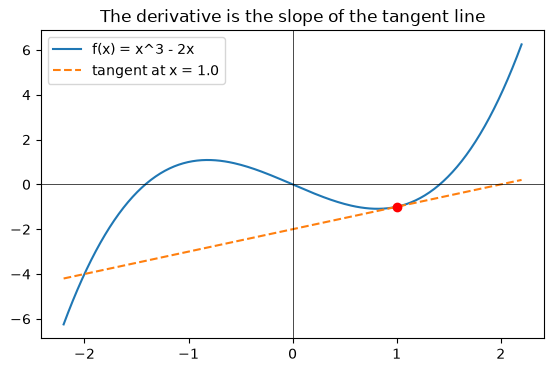

In [1]:

import numpy as np
import matplotlib.pyplot as plt

def f(x):  return x**3 - 2.0 * x
def df(x): return 3.0 * x**2 - 2.0

def num_diff(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2.0 * h)

xs = np.array([-2.0, -0.5, 0.0, 1.0, 2.5])
print(f"{'x':>6} {'analytic':>11} {'numeric':>11} {'|diff|':>10}")
for x in xs:
    a = df(x); n = num_diff(f, x)
    print(f"{x:>6.2f} {a:>11.6f} {n:>11.6f} {abs(a - n):>10.2e}")

a = 1.0
xx = np.linspace(-2.2, 2.2, 200)
plt.figure(figsize=(6.5, 4))
plt.plot(xx, f(xx), label="f(x) = x^3 - 2x")
plt.plot(xx, f(a) + df(a) * (xx - a), "--", label=f"tangent at x = {a}")
plt.plot([a], [f(a)], "ro")
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.legend(); plt.title("The derivative is the slope of the tangent line")
plt.show()


## 2. Partial derivatives and the gradient

A model's loss depends on *many* parameters: $\mathcal{L}(\theta_1, \dots, \theta_P)$. The scalar derivative generalizes one input at a time. For $f: \mathbb{R}^2 \to \mathbb{R}$ the **partial derivative** w.r.t. $x$ keeps $y$ fixed:

$$\frac{\partial f}{\partial x}(x, y) \;=\; \lim_{h \to 0} \frac{f(x+h,\, y) - f(x,\, y)}{h}$$

Stacking all partials gives the **gradient** — a vector in parameter space:

$$\nabla f(x, y) \;=\; \begin{pmatrix} \partial f / \partial x \\[2pt] \partial f / \partial y \end{pmatrix}$$

**Why the gradient is the direction of steepest ascent.** For a unit direction $u$, the rate of change of $f$ along $u$ is the directional derivative $D_u f = \nabla f \cdot u$. By Cauchy–Schwarz, $|\nabla f \cdot u| \le \|\nabla f\|$, with equality exactly when $u$ is parallel to $\nabla f$. So the gradient points *uphill* fastest, and $-\nabla f$ points downhill fastest — which is why gradient descent steps in the direction $-\nabla f$. In an LLM the parameter space has billions of dimensions, but the geometry is identical.

**Demo.** For $f(x, y) = x^2 + 2y^2$ (so $\nabla f = (2x,\, 4y)$): verify the gradient against component-wise central differences, confirm that moving along $\nabla f$ increases $f$ more than any random direction, and check that the gradient points outward (away from the minimum at the origin).

In [2]:

import numpy as np

def f2(x, y): return x**2 + 2.0 * y**2

def grad_analytic(x, y):
    return np.array([2.0 * x, 4.0 * y])

def grad_numeric(x, y, h=1e-6):
    gx = (f2(x + h, y) - f2(x - h, y)) / (2.0 * h)
    gy = (f2(x, y + h) - f2(x, y - h)) / (2.0 * h)
    return np.array([gx, gy])

pts = [(1.0, 1.0), (-1.0, 2.0), (0.5, -0.5), (-2.0, -1.0)]
print(f"{'point':>12} {'gradient':>20} {'numeric':>20} {'max err':>10}")
for (x, y) in pts:
    g = grad_analytic(x, y); gn = grad_numeric(x, y)
    print(f"({x:>4.1f},{y:>4.1f}) {str(g.round(4)):>20} {str(gn.round(4)):>20} {np.abs(g - gn).max():>10.2e}")

# steepest-ascent check: grad direction beats 2000 random directions
rng = np.random.default_rng(0)
p = np.array([1.0, 1.0])
g = grad_analytic(*p)
dirs = rng.normal(size=(2000, 2))
dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
dir_derivs = dirs @ g
print(f"\nmax directional derivative over 2000 random dirs : {dir_derivs.max():.4f}")
print(f"directional derivative along grad / ||grad||     : {g @ (g / np.linalg.norm(g)):.4f}  <- steepest")

# outward / uphill check: stepping along grad raises f
step = 0.1 * g / np.linalg.norm(g)
print(f"f(p)          = {f2(*p):.4f}")
print(f"f(p + 0.1*dir)= {f2(*(p + step)):.4f}   (uphill, as the gradient promised)")


       point             gradient              numeric    max err
( 1.0, 1.0)              [2. 4.]              [2. 4.]   1.15e-10
(-1.0, 2.0)            [-2.  8.]            [-2.  8.]   2.80e-10
( 0.5,-0.5)            [ 1. -2.]            [ 1. -2.]   5.35e-11
(-2.0,-1.0)            [-4. -4.]            [-4. -4.]   1.15e-10

max directional derivative over 2000 random dirs : 4.4720
directional derivative along grad / ||grad||     : 4.4721  <- steepest
f(p)          = 3.0000
f(p + 0.1*dir)= 3.4652   (uphill, as the gradient promised)


## 3. The chain rule

A deep network is a *composition* of differentiable functions. The derivative of a composition is a product of derivatives — that single fact is the whole of backpropagation.

**Scalar chain rule.** For $y = g(f(x))$:

$$\frac{dy}{dx} \;=\; g'\big(f(x)\big)\, f'(x)$$

**Vector chain rule and the Jacobian.** For a map $z: \mathbb{R}^n \to \mathbb{R}^m$, the derivative is the $m \times n$ **Jacobian** matrix $J_{ij} = \partial z_i / \partial x_j$. If $z = h_k \circ \cdots \circ h_1(x)$, the chain rule composes Jacobians *as matrix products*:

$$\frac{\partial z}{\partial x} \;=\; \frac{\partial z}{\partial h_k} \; \frac{\partial h_k}{\partial h_{k-1}} \; \cdots \; \frac{\partial h_1}{\partial x}$$

For our running example $z = W_2\, \mathrm{relu}(W_1 x)$ with $\mathrm{relu}(v) = \max(v, 0)$:

$$\frac{\partial z}{\partial x} \;=\; W_2 \; \underbrace{\mathrm{diag}\big(\mathbb{1}_{W_1 x > 0}\big)}_{\text{derivative of relu}} \; W_1$$

**Demo 1 (scalar).** Verify $\frac{d}{dx}\sin(x^2) = 2x\cos(x^2)$ against the central difference.

In [3]:

import numpy as np

def g(x):  return np.sin(x**2)
def dg(x): return 2.0 * x * np.cos(x**2)      # chain rule by hand

def num_diff(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2.0 * h)

xs = np.array([-1.5, -0.25, 0.7, 1.3])
print(f"{'x':>6} {'chain rule':>12} {'numeric':>12} {'|diff|':>10}")
for x in xs:
    a = dg(x); n = num_diff(g, x)
    print(f"{x:>6.2f} {a:>12.6f} {n:>12.6f} {abs(a - n):>10.2e}")


     x   chain rule      numeric     |diff|
 -1.50     1.884521     1.884521   1.45e-10
 -0.25    -0.499024    -0.499024   4.11e-12
  0.70     1.235266     1.235266   4.34e-11
  1.30    -0.309196    -0.309196   4.29e-11


In [4]:

import numpy as np

# Demo 2 (vector): full Jacobian of z = W2 @ relu(W1 @ x), 3 -> 4 -> 2 dims
rng = np.random.default_rng(42)
W1 = rng.normal(size=(4, 3))
W2 = rng.normal(size=(2, 4))
x0 = rng.normal(size=3)

def relu(v): return np.maximum(v, 0.0)

def forward(x):
    return W2 @ relu(W1 @ x)              # z in R^2, x in R^3 -> Jacobian is 2x3

def jacobian_numeric(x, h=1e-6):
    J = np.zeros((2, 3))
    for j in range(3):
        e = np.zeros(3); e[j] = 1.0
        J[:, j] = (forward(x + h * e) - forward(x - h * e)) / (2.0 * h)
    return J

# analytic chain rule: dz/dx = W2 @ diag(1_{W1 x > 0}) @ W1
h1 = W1 @ x0
D = np.diag((h1 > 0).astype(float))
J_analytic = W2 @ D @ W1

J_num = jacobian_numeric(x0)
print("analytic Jacobian (chain rule, matrix product):\n", J_analytic.round(6))
print("\nnumeric Jacobian (central differences, column by column):\n", J_num.round(6))
print(f"\nmax |analytic - numeric| = {np.abs(J_analytic - J_num).max():.2e}  -> the matrix chain rule is exact")


analytic Jacobian (chain rule, matrix product):
 [[ 0.812901 -0.972177 -0.626653]
 [ 0.267255 -0.705203  0.223139]]

numeric Jacobian (central differences, column by column):
 [[ 0.812901 -0.972177 -0.626653]
 [ 0.267255 -0.705203  0.223139]]

max |analytic - numeric| = 7.42e-11  -> the matrix chain rule is exact


## 4. Why reverse mode (backprop) beats forward mode

There are two ways to apply the chain rule to *numbers*.

**Forward mode** propagates a tangent vector $\dot{x}$ alongside the forward pass, layer by layer:

```
x ──► [W1·x + b1] ──► relu ──► [W2·h + b2] ──► relu ──► [W3·h + b3] ──► loss
 │         │                    │                    │
 └─ dx ───► dh1 ───────────────► dh2 ───────────────► dh3 ───────────► dloss
```

One tangent pass yields the derivative w.r.t. **one** input (parameter). With $P$ parameters, forward mode costs $P$ passes.

**Reverse mode** (backpropagation) first runs one forward pass storing every intermediate value, then propagates an adjoint $\bar{v} = \partial \mathcal{L}/\partial v$ backward from the loss to every parameter at once:

```
x ──► [W1·x + b1] ──► relu ──► [W2·h + b2] ──► relu ──► [W3·h + b3] ──► loss
 ▲         ▲                    ▲                    ▲
 └─ dx ◄─── dh1 ◄─────────────── dh2 ◄─────────────── dh3 ◄─────────── dloss
```

One backward pass produces all $P$ gradients: reverse mode costs $\approx 2\times$ one forward pass, *regardless of $P$*. Since $P$ is in the billions for an LLM, reverse mode is the difference between training a model and not training it.

**Demo.** Count the arithmetic operations for a tiny 3-layer MLP — forward-mode total vs reverse-mode total — then extrapolate to a 7B-parameter model.

In [5]:

# Arithmetic-op accounting for a tiny MLP with layer sizes [2, 4, 3, 1]
def linear_ops(n_in, n_out):
    # matmul: n_in*n_out multiplies + n_in*n_out adds ; bias: n_out adds
    return 2 * n_in * n_out + n_out

def relu_ops(n):
    return n

sizes = [2, 4, 3, 1]
F = 0            # ops in one forward pass
P = 0            # number of parameters (weights + biases)
for i in range(len(sizes) - 1):
    F += linear_ops(sizes[i], sizes[i + 1]) + relu_ops(sizes[i + 1])
    P += sizes[i] * sizes[i + 1] + sizes[i + 1]
F += 3           # MSE loss on the scalar output: diff, square, mean

print(f"tiny MLP layer sizes : {sizes}")
print(f"parameters P         : {P}")
print(f"ops in one forward F : {F}")
print(f"forward mode : {P} tangent passes x {F} ops = {P * F} ops   (one pass per parameter)")
print(f"reverse mode : 1 forward + 1 backward      = {2 * F} ops   (all P gradients at once)")
print(f"speedup for this MLP: {P * F / (2 * F):.1f}x")

# extrapolate to LLM scale: ~6 ops per parameter per forward pass is a common rule of thumb
P_llm = 7_000_000_000
F_llm = 6 * P_llm
print(f"\n7B-parameter LLM : forward mode ~ {P_llm * F_llm:.2e} ops")
print(f"                  reverse mode ~ {2 * F_llm:.2e} ops  (a {P_llm / 2:.1e}x saving)")
print("this is why every deep-learning framework trains with backpropagation")


tiny MLP layer sizes : [2, 4, 3, 1]
parameters P         : 31
ops in one forward F : 65
forward mode : 31 tangent passes x 65 ops = 2015 ops   (one pass per parameter)
reverse mode : 1 forward + 1 backward      = 130 ops   (all P gradients at once)
speedup for this MLP: 15.5x

7B-parameter LLM : forward mode ~ 2.94e+20 ops
                  reverse mode ~ 8.40e+10 ops  (a 3.5e+09x saving)
this is why every deep-learning framework trains with backpropagation


## 5. Build a mini autodiff engine (the centerpiece)

Every deep-learning framework — PyTorch, JAX, TensorFlow — is a machine for the reverse chain rule. Here we build a minimal one from scratch, in the spirit of micrograd: a `Value` that holds a number and its gradient, remembers the graph of operations that produced it, and can propagate gradients backward through that graph.

The design has exactly three parts:

1. **Forward pass builds a graph.** Every `+`, `*`, and `relu` creates a new `Value` that records its parents (`_prev`) and a local backward function (`_backward`) implementing the derivative of *that one op*:
   - $\partial(a+b)/\partial a = 1$, $\partial(a+b)/\partial b = 1$
   - $\partial(a \cdot b)/\partial a = b$, $\partial(a \cdot b)/\partial b = a$
   - $\partial\,\mathrm{relu}(a)/\partial a = \mathbb{1}_{a > 0}$
2. **`backward()` topologically sorts the graph** (children before parents), seeds the output gradient with $1$, and calls each node's local backward in reverse order — this *is* the chain rule, applied to numbers.
3. **Gradients accumulate with `+=`**, because a node can appear in several paths from the loss (the multivariate chain rule sums over paths).

The engine is pure Python floats — NumPy enters only to generate the training data. ~60 lines.

In [6]:

# ---- a minimal reverse-mode autodiff engine: +, *, relu, backward() ----
class Value:
    def __init__(self, data, children=(), op=""):
        self.data = float(data)
        self.grad = 0.0
        self._prev = set(children)
        self._op = op
        self._backward = lambda: None          # local derivative rule, filled by ops

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _bw():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _bw
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _bw():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _bw
        return out

    def __rmul__(self, other):
        return self * other

    def relu(self):
        out = Value(max(0.0, self.data), (self,), "relu")
        def _bw():
            self.grad += (1.0 if self.data > 0.0 else 0.0) * out.grad
        out._backward = _bw
        return out

    def backward(self):
        topo, seen = [], set()
        def build(v):
            if v not in seen:
                seen.add(v)
                for p in v._prev:
                    build(p)
                topo.append(v)
        build(self)
        self.grad = 1.0                        # d(out)/d(out) = 1
        for v in reversed(topo):
            v._backward()                      # chain rule, in reverse topological order

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

# ---- smoke test: d/da (a*b + c) at a=3, b=4, c=5 ----
a = Value(3.0); b = Value(4.0); c = Value(5.0)
out = a * b + c
out.backward()
print("out =", out.data, " (expect 17)")
print("da  =", a.grad,  " (expect 4)")
print("db  =", b.grad,  " (expect 3)")
print("dc  =", c.grad,  " (expect 1)")


out = 17.0  (expect 17)
da  = 4.0  (expect 4)
db  = 3.0  (expect 3)
dc  = 1.0  (expect 1)


step   0  loss = 2.108897
step  10  loss = 0.003348
step  20  loss = 0.001505
step  30  loss = 0.001502
step  40  loss = 0.001502
step  50  loss = 0.001502
step  60  loss = 0.001502
step  70  loss = 0.001502
step  80  loss = 0.001502
step  90  loss = 0.001502

learned w = 2.0279   (true 2.0)
learned b = 0.9586   (true 1.0)


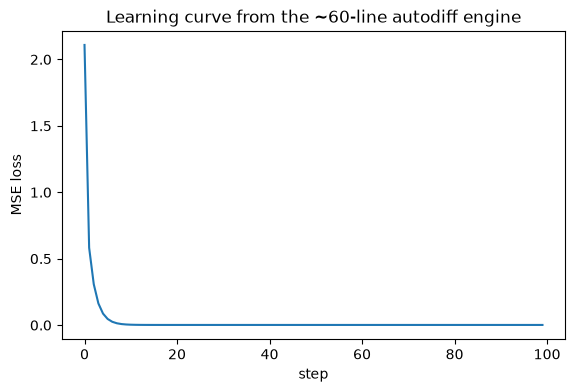

In [7]:

import numpy as np
import matplotlib.pyplot as plt

# ---- train y = 2x + 1 + noise with the engine (numpy only for data) ----
rng = np.random.default_rng(7)
xs = rng.uniform(-1.0, 1.0, 16)
ys = 2.0 * xs + 1.0 + rng.normal(0.0, 0.05, 16)

w = Value(0.0); b = Value(0.0)                 # the two learnable parameters
lr = 0.5
losses = []
for step in range(100):
    total = Value(0.0)
    for xi, yi in zip(xs, ys):
        yhat = w * Value(xi) + b               # forward: linear model
        d = yhat + Value(-yi)                  # residual (engine has no __sub__: negate)
        total = total + d * d                  # accumulate squared error
    loss = total * Value(1.0 / len(xs))        # mean squared error
    losses.append(loss.data)
    loss.backward()                            # one backward pass -> both gradients
    w.data -= lr * w.grad                      # gradient descent step
    b.data -= lr * b.grad
    w.grad = 0.0; b.grad = 0.0                 # engine accumulates: reset before next pass
    if step % 10 == 0:
        print(f"step {step:3d}  loss = {loss.data:.6f}")

print(f"\nlearned w = {w.data:.4f}   (true 2.0)")
print(f"learned b = {b.data:.4f}   (true 1.0)")

plt.figure(figsize=(6.5, 4))
plt.plot(losses)
plt.xlabel("step"); plt.ylabel("MSE loss")
plt.title("Learning curve from the ~60-line autodiff engine")
plt.show()


## 6. Gradient checking — the honest scientist's step

A gradient that is *wrong but plausible-looking* silently corrupts every downstream step. The standard safeguard — used in research code and in this curriculum's master report — is to compare analytic/engine gradients against the central difference (Section 1) on a small random graph. If the relative error is below ~$10^{-5}$, the backpropagation is almost certainly correct.

**Demo.** Build a random graph with the engine — including a `relu` and a *reused* leaf (which forces gradient accumulation) — run `backward()`, and compare every parameter's gradient against finite differences.

In [8]:

import numpy as np

def build_graph(vals):
    # rebuilds the same graph shape from leaf values; 'a' is used twice on purpose
    a = Value(vals["a"]); b = Value(vals["b"])
    c = Value(vals["c"]); d = Value(vals["d"])
    t = (a * b + c).relu()
    out = t * d + a                            # a appears again -> gradient accumulation
    return out, {"a": a, "b": b, "c": c, "d": d}

leaves = {"a": 0.7, "b": -1.3, "c": 0.5, "d": 2.1}
out, params = build_graph(leaves)
out.backward()

def numeric_grad(name, h=1e-6):
    plus = build_graph({**leaves, name: leaves[name] + h})[0].data
    minus = build_graph({**leaves, name: leaves[name] - h})[0].data
    return (plus - minus) / (2.0 * h)

all_ok = True
print(f"{'param':>6} {'engine':>14} {'numeric':>14} {'|diff|':>10}  verdict")
for name, v in params.items():
    ng = numeric_grad(name)
    ok = abs(ng - v.grad) < 1e-5
    all_ok = all_ok and ok
    print(f"{name:>6} {v.grad:>14.8f} {ng:>14.8f} {abs(ng - v.grad):>10.2e}  {'OK' if ok else 'MISMATCH'}")

print("\nALL GRADIENTS OK — backpropagation from scratch verified against finite differences" if all_ok
      else "\nGRADIENT CHECK FAILED — inspect the engine")


 param         engine        numeric     |diff|  verdict
     a     1.00000000     1.00000000   2.88e-11  OK
     b     0.00000000     0.00000000   0.00e+00  OK
     c     0.00000000     0.00000000   0.00e+00  OK
     d     0.00000000     0.00000000   0.00e+00  OK

ALL GRADIENTS OK — backpropagation from scratch verified against finite differences


## 7. Exercises

1. **Chain rule by hand.** Derive $f'(x)$ for $f(x) = e^{x^2}$. Then verify it numerically with the central difference at $x = 0.3$. *Hint: let $u = x^2$; then $f = e^u$ and $f' = e^u \cdot du/dx$.*
2. **Gradient geometry.** For $f(x, y) = x^2 + 2y^2$, compute $\nabla f$ at $(3, -1)$. In which unit direction does $f$ increase fastest, and what is the slope in that direction? *Hint: steepest ascent is $\nabla f / \|\nabla f\|$; the slope is $\|\nabla f\|$.*
3. **Jacobian dimensions.** With $x \in \mathbb{R}^3$, $W_1 \in \mathbb{R}^{4\times 3}$, $W_2 \in \mathbb{R}^{2\times 4}$ and $z = W_2\,\mathrm{relu}(W_1 x)$: what are the dimensions of $\partial z / \partial x$, and how many entries does it have? *Hint: count the matrix dimensions in the chain rule $W_2\,D\,W_1$.*
4. **Why store the graph?** In the mini engine, `backward()` needs the *values* of both parents of every `*` and the pre-activation of every `relu`. What would break if each node stored only its output data? *Hint: look at the local rules — what does $\partial(a \cdot b)/\partial a$ need?*
5. **Gradient accumulation.** The engine propagates with `+=`, not `=`. For the graph `(a*b + c).relu() * d + a`, how many paths carry gradient from the loss to `a`, and what would the gradient be if we used `=`? *Hint: the multivariate chain rule is a sum over paths.*

## Solutions

1. **$f'(x) = 2x\,e^{x^2}$.** With $u = x^2$: $f'(x) = e^u \cdot 2x$. At $x = 0.3$: $f'(0.3) = 0.6\,e^{0.09} \approx 0.6565$; the central difference with $h = 10^{-6}$ agrees to ~$10^{-10}$.
2. **$\nabla f(3, -1) = (6, -4)$.** Steepest ascent is the unit vector $(6,-4)/\sqrt{52} \approx (0.832, -0.555)$; the slope is $\sqrt{52} \approx 7.211$. Note the gradient points *away* from the minimum at $(0,0)$ — downhill is $-\nabla f$, which is why gradient descent steps the opposite way.
3. **$\partial z / \partial x \in \mathbb{R}^{2 \times 3}$** — six entries. Chain rule: $(2\times 4)(4\times 4)(4\times 3) \to 2\times 3$. Reverse mode computes all six (and every parameter gradient) in one backward pass.
4. **Every local rule needs parent data:** $\partial(a \cdot b)/\partial a = b$ requires $b$'s value, and the relu gate $\mathbb{1}_{a>0}$ requires the pre-activation. Without the stored graph you would have to recompute the whole forward pass per node — the O(graph) trick of backprop would be lost.
5. **Two paths:** through `t * d` (via `a*b + c`) and through the trailing `+ a`. The total derivative is the *sum* of the two path derivatives. Using `=` would keep only the last path processed in the topological order — silently wrong whenever a value is shared. This is exactly why `+=` appears in every real autodiff engine.

---
**Next →** [Workbook 03 — Probability & Statistics](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/03_Probability_and_Statistics.ipynb)

**← Back to** [The Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb)